# AUDIT ALLOCATION

Final model: weighted_rank_ensemble
NormalizedRecall@5% (OOF): 0.9683
TASK C — AUDIT ALLOCATION REPORT
 audit_pct  n_audited  n_fraud_total  n_fraud_caught  n_fraud_missed  n_non_fraud_audited  recall_at_k  precision_at_k  normalized_recall_at_k  random_baseline_expected_catch  lift_over_random
      0.03       4805          80203            4706           75497                   99       0.0587          0.9794                  0.9794                       2405.9798            1.9560
      0.05       8008          80203            7754           72449                  254       0.0967          0.9683                  0.9683                       4009.7995            1.9338
      0.07      11212          80203           10748           69455                  464       0.1340          0.9586                  0.9586                       5614.1199            1.9145


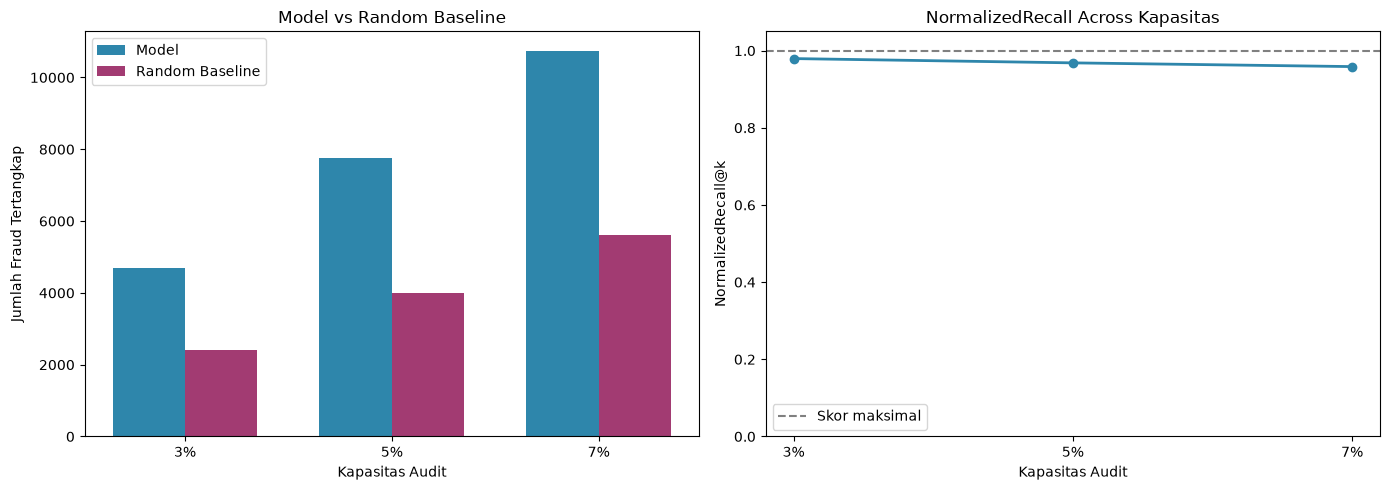

Gap skor tepat di cut-off: 0.000004
Rata-rata gap antar skor: 0.000006
>> Sensitif
Daftar audit test set (5%): 2002 klaim
             claim_id  fraud_probability  audit_rank
0  CLM_BD18924A1CDCA2           0.999466           1
1  CLM_BF64978BBAC71A           0.999466           2
2  CLM_7AF7E4E772EE0B           0.999466           3
3  CLM_D628F0B14426ED           0.999466           4
4  CLM_4BD64149290DE4           0.999466           5
5  CLM_85DB3A719E1039           0.999466           6
6  CLM_C4DD8122667469           0.999466           7
7  CLM_BCD21015137F50           0.999466           8
8  CLM_CDCE3509A82D51           0.999419           9
9  CLM_D8F868570DF680           0.999419          10


In [5]:
# Import and Load
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/Users/annya/DAC/Dataset/Processed"

y_full = np.load("/Users/annya/DAC/results/predictions/y_full.npy")
final_oof_score = np.load("/Users/annya/DAC/results/predictions/weighted_rank_oof.npy")
final_test_score = np.load("/Users/annya/DAC/results/predictions/test_weighted_rank.npy")
test_ids = pd.read_csv(f"{DATA_DIR}/test_ids.csv").squeeze()

def normalized_recall_at_k(y_true, scores, pct=0.05):
    n = len(y_true)
    k = int(np.floor(pct * n))
    order = np.argsort(-scores)
    tp_k = y_true[order[:k]].sum()
    p = y_true.sum()
    max_recall = min(k, p) / p
    return (tp_k / p) / max_recall

print(f"Final model: weighted_rank_ensemble")
print(f"NormalizedRecall@5% (OOF): {normalized_recall_at_k(y_full, final_oof_score, pct=0.05):.4f}")

# Audit Allocation function
# ============================================================
def audit_allocation_report(y_true, scores, pct):
    n = len(y_true)
    k = int(np.floor(pct * n))
    order = np.argsort(-scores)
    audited_idx = order[:k]

    n_fraud_total = int(y_true.sum())
    n_fraud_caught = int(y_true[audited_idx].sum())
    n_fraud_missed = n_fraud_total - n_fraud_caught
    n_non_fraud_audited = k - n_fraud_caught

    recall_at_k = n_fraud_caught / n_fraud_total
    precision_at_k = n_fraud_caught / k
    max_recall = min(k, n_fraud_total) / n_fraud_total
    normalized_recall = recall_at_k / max_recall

    expected_random_catch = k * (n_fraud_total / n)

    return {
        "audit_pct": pct, "n_audited": k,
        "n_fraud_total": n_fraud_total, "n_fraud_caught": n_fraud_caught,
        "n_fraud_missed": n_fraud_missed, "n_non_fraud_audited": n_non_fraud_audited,
        "recall_at_k": recall_at_k, "precision_at_k": precision_at_k,
        "normalized_recall_at_k": normalized_recall,
        "random_baseline_expected_catch": expected_random_catch,
        "lift_over_random": n_fraud_caught / expected_random_catch if expected_random_catch > 0 else np.nan,
    }

# Run in 3%, 5%, and 7%
# ============================================================
audit_pcts = [0.03, 0.05, 0.07]
audit_results = [audit_allocation_report(y_full, final_oof_score, pct) for pct in audit_pcts]
audit_df = pd.DataFrame(audit_results)

print("TASK C — AUDIT ALLOCATION REPORT")
print(audit_df.round(4).to_string(index=False))

audit_df.to_csv("/Users/annya/DAC/results/audit_allocation/audit_summary.csv", index=False)

# Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(audit_pcts))
width = 0.35

axes[0].bar(x - width/2, audit_df["n_fraud_caught"], width, label="Model", color="#2E86AB")
axes[0].bar(x + width/2, audit_df["random_baseline_expected_catch"], width, label="Random Baseline", color="#A23B72")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{int(p*100)}%" for p in audit_pcts])
axes[0].set_xlabel("Kapasitas Audit"); axes[0].set_ylabel("Jumlah Fraud Tertangkap")
axes[0].set_title("Model vs Random Baseline"); axes[0].legend()

axes[1].plot([f"{int(p*100)}%" for p in audit_pcts], audit_df["normalized_recall_at_k"], marker='o', linewidth=2, color="#2E86AB")
axes[1].axhline(1.0, linestyle='--', color='gray', label='Skor maksimal')
axes[1].set_xlabel("Kapasitas Audit"); axes[1].set_ylabel("NormalizedRecall@k")
axes[1].set_title("NormalizedRecall Across Kapasitas"); axes[1].set_ylim(0, 1.05); axes[1].legend()

plt.tight_layout()
plt.savefig("/Users/annya/DAC/outputs/figures/audit_allocation_comparison.png", dpi=150)
plt.show()

# Sensitivity Cut Off
# ============================================================
n = len(y_full)
k_5pct = int(np.floor(0.05 * n))
order = np.argsort(-final_oof_score)
sorted_scores = final_oof_score[order]

gap_at_cutoff = sorted_scores[k_5pct - 1] - sorted_scores[k_5pct]
avg_gap_elsewhere = np.mean(np.abs(np.diff(sorted_scores)))

print(f"Gap skor tepat di cut-off: {gap_at_cutoff:.6f}")
print(f"Rata-rata gap antar skor: {avg_gap_elsewhere:.6f}")
print(">> Sensitif" if gap_at_cutoff < avg_gap_elsewhere else ">> Aman, tidak terlalu sensitif")

# Generate an Audit List For the Test Set
# ============================================================
def generate_audit_list(scores, ids, pct):
    n = len(scores)
    k = int(np.floor(pct * n))
    order = np.argsort(-scores)
    audited_idx = order[:k]
    return pd.DataFrame({
        "claim_id": np.array(ids)[audited_idx],
        "fraud_probability": scores[audited_idx],
        "audit_rank": np.arange(1, k + 1)
    })

for pct in [0.03, 0.05, 0.07]:
    audit_list = generate_audit_list(final_test_score, test_ids, pct=pct)
    audit_list.to_csv(f"/Users/annya/DAC/results/audit_allocation/audit_list_test_{int(pct*100)}pct.csv", index=False)

audit_list_5pct = generate_audit_list(final_test_score, test_ids, pct=0.05)
print(f"Daftar audit test set (5%): {len(audit_list_5pct)} klaim")
print(audit_list_5pct.head(10))